# DAY6 SciPy 常用函数学习

今天学习 SciPy。它建立在 NumPy 上，主要负责科学计算中更专业的工作，比如统计检验、方程求解、积分、插值和信号处理。

这份笔记以常用函数为主。每一部分都先说明用途，再用一个小例子观察结果。第一次学习不用背函数名，先知道遇到什么问题该去哪个模块找。

In [1]:
# 如果导入时报错，可以去掉下一行前面的 #，运行一次安装命令
# %pip install scipy

import numpy as np
import matplotlib.pyplot as plt
import scipy

np.set_printoptions(precision=4, suppress=True)
print('SciPy版本：', scipy.__version__)

SciPy版本： 1.18.0


SciPy 不是把所有函数都放在最外层，而是按用途分模块。例如 `scipy.stats` 管统计，`scipy.optimize` 管优化。平时常用 `from scipy import stats` 这种方式导入。

In [2]:
# constants 中保存了很多科学常数和单位换算值
from scipy import constants

print('圆周率：', constants.pi)
print('光速（米/秒）：', constants.c)
print('重力加速度（米/秒²）：', constants.g)
print('1英里等于多少米：', constants.mile)
print('1英寸等于多少米：', constants.inch)

圆周率： 3.141592653589793
光速（米/秒）： 299792458.0
重力加速度（米/秒²）： 9.80665
1英里等于多少米： 1609.3439999999998
1英寸等于多少米： 0.0254


## 1. 线性代数 `scipy.linalg`

NumPy 也能做线性代数。SciPy 提供的函数更多，处理方程组、矩阵分解时更方便。

In [2]:
from scipy import linalg

# 解方程组：2x + y = 5，x - y = 1
A = np.array([[2, 1], [1, -1]])
b = np.array([5, 1])
x = linalg.solve(A, b)

print('方程的解：', x)
print('代回去检查 A @ x：', A @ x)
print('行列式：', linalg.det(A))
print('逆矩阵：\n', linalg.inv(A))

方程的解： [2. 1.]
代回去检查 A @ x： [5. 1.]
行列式： -3.0
逆矩阵：
 [[ 0.3333  0.3333]
 [ 0.3333 -0.6667]]


In [4]:
matrix = np.array([[4, 2], [1, 3]])

# norm求向量或矩阵的长度，eig求特征值和特征向量
print('矩阵的范数：', linalg.norm(matrix))
eigenvalues, eigenvectors = linalg.eig(matrix)
print('特征值：', eigenvalues)
print('特征向量：\n', eigenvectors)

# SVD奇异值分解，数据降维时会用到
U, singular_values, Vh = linalg.svd(matrix)
print('奇异值：', singular_values)

矩阵的范数： 5.477225575051661
特征值： [5.+0.j 2.+0.j]
特征向量：
 [[ 0.8944 -0.7071]
 [ 0.4472  0.7071]]
奇异值： [5.1167 1.9544]


## 2. 统计分析 `scipy.stats`

`stats` 是数据分析中最常用的 SciPy 模块。它可以计算统计量、生成概率分布，还能做 t 检验、相关性检验和卡方检验。

In [5]:
from scipy import stats

scores = np.array([78, 85, 92, 88, 76, 95, 84, 90])
result = stats.describe(scores)

print('样本数量：', result.nobs)
print('最小值和最大值：', result.minmax)
print('平均值：', result.mean)
print('样本方差：', result.variance)
print('标准分数 z-score：', stats.zscore(scores))
print('众数：', stats.mode(scores))

样本数量： 8
最小值和最大值： (np.int64(76), np.int64(95))
平均值： 86.0
样本方差： 43.714285714285715
标准分数 z-score： [-1.2935 -0.1617  0.9701  0.3234 -1.6169  1.4552 -0.3234  0.6468]
众数： ModeResult(mode=np.int64(76), count=np.int64(1))


In [6]:
# 正态分布：loc是均值，scale是标准差
normal = stats.norm(loc=100, scale=15)

print('分数小于等于115的概率：', normal.cdf(115))       # cdf累计概率
print('前95%对应的分数：', normal.ppf(0.95))           # ppf反查数值
print('100这一点的概率密度：', normal.pdf(100))         # pdf概率密度
print('随机生成5个分数：', normal.rvs(size=5, random_state=42))

分数小于等于115的概率： 0.8413447460685429
前95%对应的分数： 124.67280440427209
100这一点的概率密度： 0.02659615202676218
随机生成5个分数： [107.4507  97.926  109.7153 122.8454  96.4877]


In [7]:
# 单样本t检验：判断这组成绩的平均值是否和80有明显差异
one_sample = stats.ttest_1samp(scores, popmean=80)
print('单样本t检验：', one_sample)

class_a = np.array([82, 85, 88, 90, 86, 84])
class_b = np.array([76, 79, 81, 78, 80, 77])
# 独立样本t检验：比较两个班的平均成绩
two_sample = stats.ttest_ind(class_a, class_b, equal_var=False)
print('两个班的t检验：', two_sample)
print('p值：', two_sample.pvalue)

# 常用判断：p < 0.05，说明差异有统计学意义，但不等于差异一定很大

单样本t检验： TtestResult(statistic=np.float64(2.566755791678992), pvalue=np.float64(0.037183381084283734), df=np.int64(7))
两个班的t检验： TtestResult(statistic=np.float64(5.25900588107133), pvalue=np.float64(0.0006003156581975395), df=np.float64(8.620689655172415))
p值： 0.0006003156581975395


In [8]:
study_hours = np.array([1, 2, 3, 4, 5, 6, 7])
exam_scores = np.array([55, 60, 68, 72, 80, 87, 91])

# Pearson适合看线性相关，Spearman适合看排名或单调关系
pearson = stats.pearsonr(study_hours, exam_scores)
spearman = stats.spearmanr(study_hours, exam_scores)
print('Pearson相关系数和p值：', pearson)
print('Spearman相关系数和p值：', spearman)

Pearson相关系数和p值： PearsonRResult(statistic=np.float64(0.997171512177241), pvalue=np.float64(8.159832351291406e-07))
Spearman相关系数和p值： SignificanceResult(statistic=np.float64(1.0), pvalue=np.float64(0.0))


In [9]:
# 卡方检验：判断两个分类变量是否有关联
# 行表示是否参加辅导，列表示考试通过或未通过
table = np.array([[45, 15], [30, 30]])
chi2, p_value, dof, expected = stats.chi2_contingency(table)
print('卡方统计量：', chi2)
print('p值：', p_value)
print('自由度：', dof)
print('理论频数：\n', expected)

卡方统计量： 6.968888888888888
p值： 0.008293898079160133
自由度： 1
理论频数：
 [[37.5 22.5]
 [37.5 22.5]]


## 3. 求根与优化 `scipy.optimize`

求根是找出函数等于 0 的位置，优化是找函数的最小值或最大值。SciPy 默认求最小值，求最大值时可以把函数取负数。

In [10]:
from scipy import optimize

# 求 x² - 2 = 0，也就是求根号2
def equation(x):
    return x ** 2 - 2

root_result = optimize.root_scalar(equation, bracket=[1, 2])#搜索范围1~2
print('方程的根：', root_result.root)
print('是否成功：', root_result.converged)

方程的根： 1.4142135623731364
是否成功： True


In [11]:
# 找 (x - 3)² + 2 的最小值
def cost(x):
    return (x - 3) ** 2 + 2

minimum = optimize.minimize_scalar(cost)
print('最小值所在的x：', minimum.x)
print('函数最小值：', minimum.fun)

# 多变量函数使用 minimize，x0是初始猜测
def cost_2d(point):
    x, y = point
    return (x - 2) ** 2 + (y + 1) ** 2

minimum_2d = optimize.minimize(cost_2d, x0=[0, 0])
print('二维函数最小点：', minimum_2d.x)

最小值所在的x： 3.0
函数最小值： 2.0
二维函数最小点： [ 2. -1.]


斜率： 2.03428571468944 截距： 0.9133333314230687


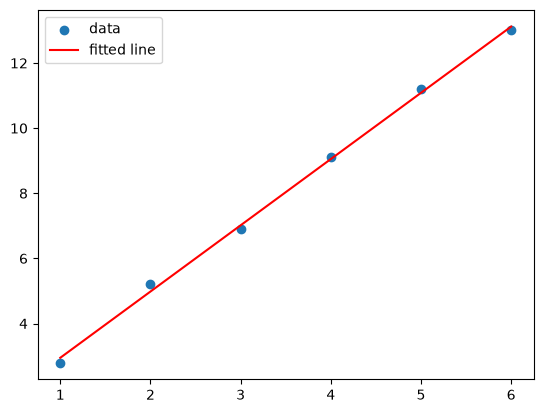

In [12]:
# curve_fit用来拟合自定义曲线
def linear_model(x, slope, intercept):
    return slope * x + intercept

x_data = np.array([1, 2, 3, 4, 5, 6])
y_data = np.array([2.8, 5.2, 6.9, 9.1, 11.2, 13.0])
parameters, covariance = optimize.curve_fit(linear_model, x_data, y_data)
slope, intercept = parameters
print('斜率：', slope, '截距：', intercept)

plt.scatter(x_data, y_data, label='data')
plt.plot(x_data, linear_model(x_data, slope, intercept), color='red', label='fitted line')
plt.legend()
plt.show()

## 4. 数值积分 `scipy.integrate`

积分可以理解成求曲线下面的面积。已知函数时常用 `quad`，只有一组离散数据时常用 `trapezoid`。

In [13]:
from scipy import integrate

# 计算 x² 在0到2之间的积分，正确答案是8/3
area, error = integrate.quad(lambda x: x ** 2, 0, 2)
print('积分结果：', area)
print('估计误差：', error)

积分结果： 2.666666666666667
估计误差： 2.960594732333751e-14


In [14]:
time = np.array([0, 1, 2, 3, 4])
speed = np.array([0, 3, 5, 4, 2])

# 速度对时间积分，可以估算路程
distance = integrate.trapezoid(speed, time)
cumulative_distance = integrate.cumulative_trapezoid(speed, time, initial=0)
print('总路程：', distance)
print('每个时刻的累计路程：', cumulative_distance)

总路程： 13.0
每个时刻的累计路程： [ 0.   1.5  5.5 10.  13. ]


## 5. 插值 `scipy.interpolate`

插值是根据已知点估算中间的未知值。直线插值简单稳定，三次样条曲线更平滑。数据范围外的预测不属于插值，要更加谨慎。

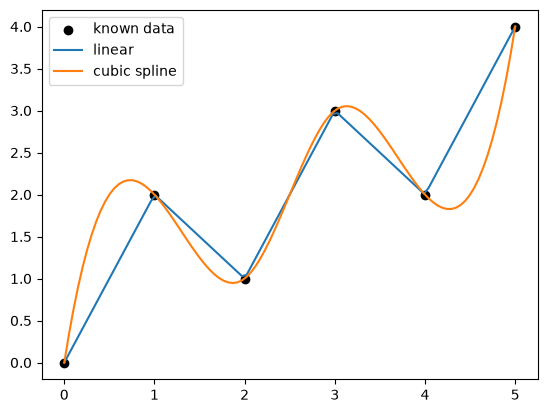

In [15]:
from scipy import interpolate

x_known = np.array([0, 1, 2, 3, 4, 5])
y_known = np.array([0, 2, 1, 3, 2, 4])
x_new = np.linspace(0, 5, 100)

linear_y = np.interp(x_new, x_known, y_known)
cubic_model = interpolate.CubicSpline(x_known, y_known)
cubic_y = cubic_model(x_new)

plt.scatter(x_known, y_known, color='black', label='known data')
plt.plot(x_new, linear_y, label='linear')
plt.plot(x_new, cubic_y, label='cubic spline')
plt.legend()
plt.show()

## 6. 傅里叶变换 `scipy.fft`

傅里叶变换可以把时域信号拆成不同频率。音频分析、周期检测和滤波中经常会用到。

最明显的两个频率： [ 5. 12.]


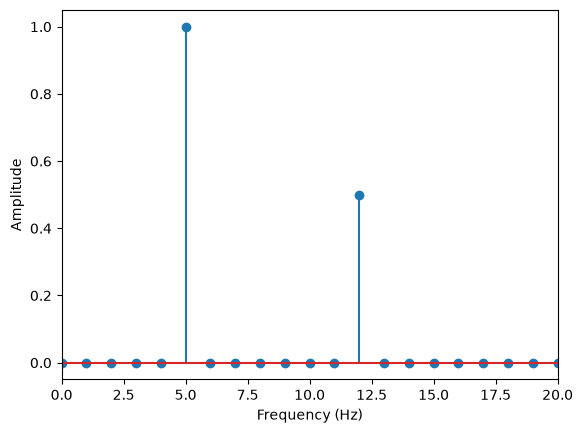

In [16]:
from scipy import fft

sample_rate = 100
time = np.arange(0, 1, 1 / sample_rate)
signal_data = np.sin(2 * np.pi * 5 * time) + 0.5 * np.sin(2 * np.pi * 12 * time)

frequency_values = fft.rfftfreq(len(signal_data), d=1 / sample_rate)
amplitudes = np.abs(fft.rfft(signal_data)) * 2 / len(signal_data)
peak_indices = np.argsort(amplitudes)[-2:]
print('最明显的两个频率：', np.sort(frequency_values[peak_indices]))

plt.stem(frequency_values, amplitudes)
plt.xlim(0, 20)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()

## 7. 信号处理 `scipy.signal`

`signal` 可以平滑带噪声的数据、寻找峰值和设计滤波器。下面用一条带噪声的曲线练习。

峰值位置： [ 14  87 152]


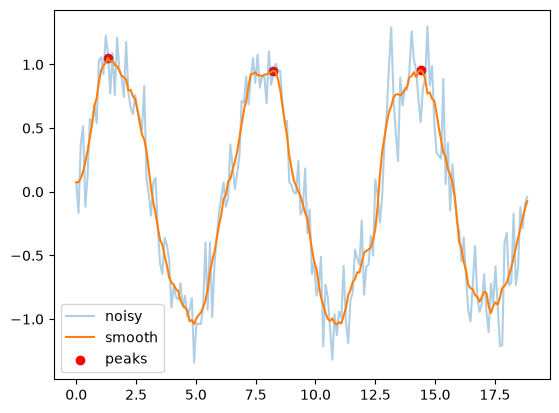

In [17]:
from scipy import signal

rng = np.random.default_rng(42)
x = np.linspace(0, 6 * np.pi, 200)
noisy_signal = np.sin(x) + rng.normal(0, 0.25, size=x.size)

# window_length窗口长度必须是奇数，polyorder是拟合多项式次数
smooth_signal = signal.savgol_filter(noisy_signal, window_length=15, polyorder=3)#主要的滤波函数 窗口长度 拟合多项式次数
peaks, properties = signal.find_peaks(smooth_signal, height=0.7, distance=30)
print('峰值位置：', peaks)

plt.plot(x, noisy_signal, alpha=0.35, label='noisy')
plt.plot(x, smooth_signal, label='smooth')
plt.scatter(x[peaks], smooth_signal[peaks], color='red', label='peaks')
plt.legend()
plt.show()

## 8. 距离与空间计算 `scipy.spatial`

空间计算不只是地图坐标。只要一行数据能看成一个点，就可以计算距离、寻找最近邻。

In [18]:
from scipy.spatial import distance

point_a = np.array([1, 2])
point_b = np.array([4, 6])
print('欧氏距离：', distance.euclidean(point_a, point_b))
print('曼哈顿距离：', distance.cityblock(point_a, point_b))
print('余弦距离：', distance.cosine(point_a, point_b))

group_a = np.array([[0, 0], [1, 1], [2, 2]])
group_b = np.array([[0, 1], [3, 3]])
print('两组点两两之间的距离：\n', distance.cdist(group_a, group_b))

欧氏距离： 5.0
曼哈顿距离： 7
余弦距离： 0.007722123286332261
两组点两两之间的距离：
 [[1.     4.2426]
 [1.     2.8284]
 [2.2361 1.4142]]


In [19]:
from scipy.spatial import KDTree

shops = np.array([[1, 1], [2, 5], [5, 4], [7, 2]])
tree = KDTree(shops)
query_point = np.array([4, 3])
nearest_distance, nearest_index = tree.query(query_point)
print('最近商店的坐标：', shops[nearest_index])
print('距离：', nearest_distance)

最近商店的坐标： [5 4]
距离： 1.4142135623730951


## 9. 稀疏矩阵 `scipy.sparse`

当矩阵里大部分都是 0 时，直接保存整个矩阵会浪费内存。稀疏矩阵只记录非零值和它们的位置。

In [20]:
from scipy import sparse
from scipy.sparse import linalg as sparse_linalg

dense_matrix = np.array([[3, 0, 0], [0, 4, 0], [1, 0, 5]])
csr = sparse.csr_matrix(dense_matrix)
print('非零元素个数：', csr.nnz)
print('稀疏矩阵内容：\n', csr)
print('转回普通数组：\n', csr.toarray())

# 稀疏矩阵也可以直接解方程组
b = np.array([6, 8, 11])
print('稀疏方程组的解：', sparse_linalg.spsolve(csr, b))

非零元素个数： 4
稀疏矩阵内容：
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (3, 3)>
  Coords	Values
  (0, 0)	3
  (1, 1)	4
  (2, 0)	1
  (2, 2)	5
转回普通数组：
 [[3 0 0]
 [0 4 0]
 [1 0 5]]
稀疏方程组的解： [2.  2.  1.8]


## 10. 图像与多维数组处理 `scipy.ndimage`

图像本质上也是 NumPy 数组。`ndimage` 可以做模糊、旋转、缩放和边缘处理。

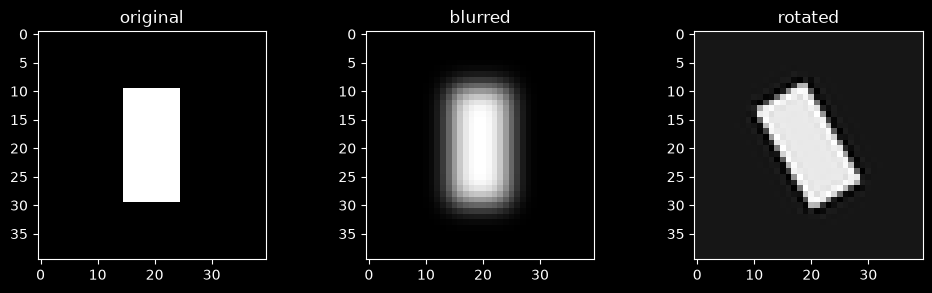

In [7]:
from scipy import ndimage

image = np.zeros((40, 40))
image[10:30, 15:25] = 1#竖着10~30 横着15~25
blurred = ndimage.gaussian_filter(image, sigma=2)
rotated = ndimage.rotate(image, angle=30, reshape=False)

figure, axes = plt.subplots(1, 3, figsize=(10, 3))
for axis, data, title in zip(axes, [image, blurred, rotated], ['original', 'blurred', 'rotated']):
    axis.imshow(data, cmap='gray')
    axis.set_title(title)
    axis.axis('on')
plt.tight_layout()
plt.show()

## 11. 特殊数学函数 `scipy.special`

这里放的是普通数学库里不常见，但在概率、机器学习和工程计算中经常出现的函数。

In [22]:
from scipy import special

print('5的阶乘：', special.factorial(5))
print('从10个中选3个的组合数：', special.comb(10, 3))
print('Gamma(5)：', special.gamma(5))
print('Sigmoid：', special.expit(np.array([-2, 0, 2])))
print('Softmax：', special.softmax(np.array([1.0, 2.0, 3.0])))

# gamma(n) = (n-1)!，所以Gamma(5)等于4!

5的阶乘： 120.0
从10个中选3个的组合数： 120.0
Gamma(5)： 24.0
Sigmoid： [0.1192 0.5    0.8808]
Softmax： [0.09   0.2447 0.6652]


## 常用函数速查

| 遇到的问题 | 模块 | 常用函数 |
|---|---|---|
| 解方程组、矩阵分解 | `linalg` | `solve`、`det`、`eig`、`svd` |
| 描述统计、概率分布 | `stats` | `describe`、`zscore`、`norm` |
| 比较均值、检验关联 | `stats` | `ttest_1samp`、`ttest_ind`、`chi2_contingency` |
| 相关性分析 | `stats` | `pearsonr`、`spearmanr` |
| 求根、找最小值、拟合 | `optimize` | `root_scalar`、`minimize`、`curve_fit` |
| 求曲线下面积 | `integrate` | `quad`、`trapezoid` |
| 补出中间数据 | `interpolate` | `CubicSpline` |
| 分析频率 | `fft` | `rfft`、`rfftfreq` |
| 平滑曲线、找峰值 | `signal` | `savgol_filter`、`find_peaks` |
| 计算距离、找最近点 | `spatial` | `cdist`、`KDTree` |
| 存储大量0的矩阵 | `sparse` | `csr_matrix`、`spsolve` |
| 图像模糊、旋转 | `ndimage` | `gaussian_filter`、`rotate` |



1. 用 `linalg.solve` 解方程组：`x + y = 7`，`2x - y = 2`。
2. 一组商品评分是 `[4.2, 4.5, 3.8, 4.9, 4.1, 4.6]`，用 `stats.describe` 查看平均值和方差。
3. 用 `optimize.root_scalar` 求 `x³ - 8 = 0` 的根。
4. 用 `integrate.quad` 计算 `sin(x)` 从 0 到 π 的积分。
5. 把信号 `[0, 1, 0, 2, 0, 1, 0]` 中高度大于 0.5 的峰值找出来。

In [24]:

# 1
#linalg.solve([[1, 1], [2, -1]], [7, 2])

# 2
#stats.describe([4.2, 4.5, 3.8, 4.9, 4.1, 4.6])

# 3
#optimize.root_scalar(lambda x: x ** 3 - 8, bracket=[1, 3]).root

# 4
#integrate.quad(np.sin, 0, np.pi)

# 5
#signal.find_peaks([0, 1, 0, 2, 0, 1, 0], height=0.5)





今天先认识了 SciPy 的主要模块，并练习了常用函数。NumPy 负责数组和基础计算，SciPy 更像一个科学计算工具箱。以后碰到统计检验、优化、积分或信号处理问题，可以先查速查表找到对应模块，再看函数参数。